In [1]:
import pandas as pd

P = 1

df = pd.read_csv(f"data/data_sip{P}.csv")

time_series_s = pd.DataFrame(columns=['id', 'values'])

for i, patient in enumerate(pd.unique(df["idx"])):

    # initialize empty list for SI values
    current_SI_vals = []

    # get subset of patient rows from full dataset
    df_current = df.loc[df['idx'] == patient]

    # append all SI values to list
    current_SI_vals.append(df_current.iloc[0]['SIM1'])
    current_SI_vals += [val for val in df_current['SI']]
    current_SI_vals.append(df_current.iloc[-1][f'SIP{P}'])
    time_series_s.at[i, 'id'] = patient
    time_series_s.at[i, 'values'] = current_SI_vals

time_series_s.tail()

,id,values
1874,2343,"[0.0001985559336252, 0.0002022872843766, 0.000..."
1875,2344,"[0.0, 0.0, 3.83326041899691e-05, 1.18745078837..."
1876,2345,"[0.0, 5.65286046647096e-05, 0.0001041227757138..."
1877,2348,"[9.67123562133826e-05, 0.0001590601729992, 0.0..."
1878,2349,"[0.0001521466986125, 0.0002270374490172, 0.000..."


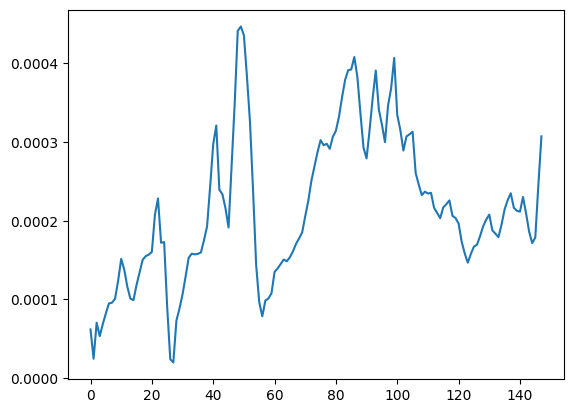

In [2]:
import matplotlib.pyplot as plt
plt.plot(time_series_s.at[0, 'values'])
plt.show()


In [3]:
len_s = []
for row in time_series_s.iterrows():
    len_s.append(len(row[1][1]))

In [4]:
import numpy as np

minimum length =  11
maximum length =  788
average length =  67.98616285258116
median length =  44.0


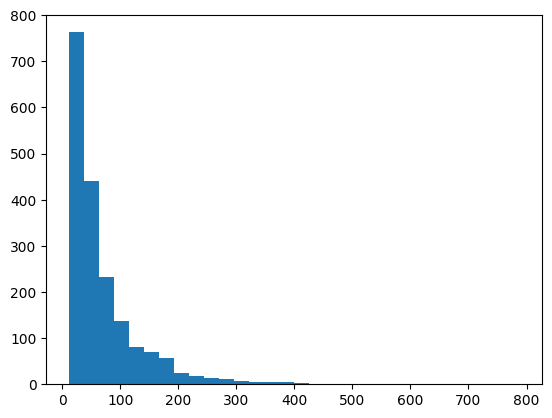

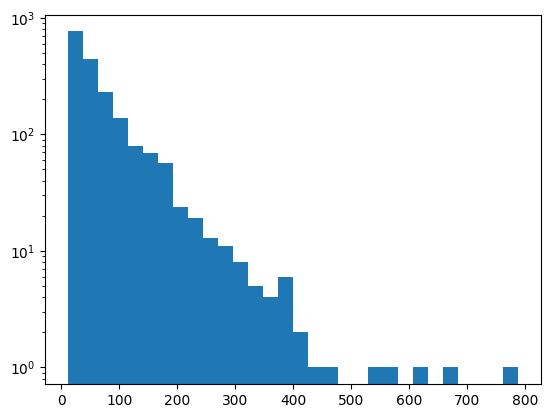

In [5]:
print('minimum length = ', min(len_s))
print('maximum length = ', max(len_s))
print('average length = ', np.average(len_s))
print('median length = ', np.median(len_s))
plt.hist(len_s, bins=30)
plt.show()
plt.hist(len_s, bins=30)
plt.yscale('log')
plt.show()

In [27]:
chunk_len = 15
step_len = 17

# TODO add these to variable parameters upon checking

chunks = []
for time_series in time_series_s.iterrows():
    values = time_series[1]['values']
    while len(values) > chunk_len - 1:
        chunks.append(values[0:chunk_len])
        try:
            values = values[step_len:]
        except:
            break

print('Number of chunks:', len(chunks))

Number of chunks: 6831


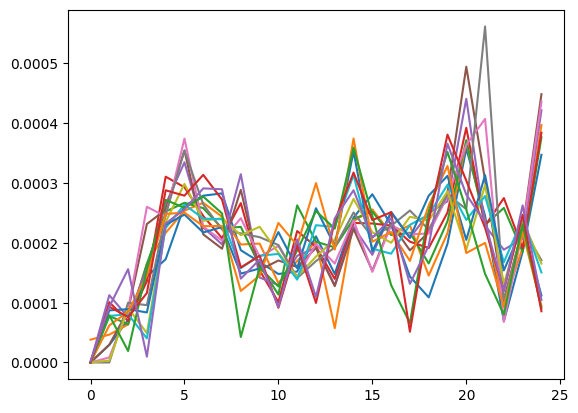

In [28]:
fig, ax = plt.subplots()
ax.plot(chunks[10:35])
plt.show()